In [ ]:
!git clone https://github.com/elliotcanter11/Diff-Pruning.git

Cloning into 'Diff-Pruning'...
remote: Enumerating objects: 998, done.
remote: Counting objects: 100% (414/414), done.
remote: Compressing objects: 100% (257/257), done.
remote: Total 998 (delta 203), reused 308 (delta 134), pack-reused 584 (from 1)
Receiving objects: 100% (998/998), 25.75 MiB | 20.91 MiB/s, done.
Resolving deltas: 100% (449/449), done.


In [ ]:
%cd Diff-Pruning/

/content/Diff-Pruning


In [ ]:
!ls

assets		ddpm_train.py  ldm_exp	     requirements.txt
ddpm_exp	diffusers      ldm_prune.py  scripts
ddpm_prune.py	fid_score.py   LICENSE	     tools
ddpm_sample.py	inception.py   README.md     utils.py


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.0 MB/s eta 0:00:00


In [ ]:
#Download and extract CIFAR-10 images to data/cifar10_images for training and evaluation.
!python tools/extract_cifar10_hug.py --output data

README.md: 100% 5.16k/5.16k [00:00<00:00, 17.3MB/s]
plain_text/train-00000-of-00001.parquet: 100% 120M/120M [00:01<00:00, 76.8MB/s]
plain_text/test-00000-of-00001.parquet: 100% 23.9M/23.9M [00:01<00:00, 23.8MB/s]
Generating train split: 100% 50000/50000 [00:00<00:00, 99847.64 examples/s] 
Generating test split: 100% 10000/10000 [00:00<00:00, 118754.55 examples/s]
100% 50000/50000 [00:30<00:00, 1613.23it/s]


In [ ]:
#The following script will download an official DDPM model and convert it to the format of Huggingface Diffusers.
#You can find the converted model at pretrained/ddpm_ema_cifar10. It is an EMA version of google/ddpm-cifar10-32
!bash tools/convert_cifar10_ddpm_ema.sh

--2026-07-08 15:44:36--  https://heibox.uni-heidelberg.de/f/2e4f01e2d9ee49bab1d5/?dl=1
Resolving heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)... 129.206.7.113
Connecting to heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)|129.206.7.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://heibox.uni-heidelberg.de/seafhttp/files/6a8dc0f5-ccac-4189-a199-58f7a1712e80/model-790000.ckpt [following]
--2026-07-08 15:44:37--  https://heibox.uni-heidelberg.de/seafhttp/files/6a8dc0f5-ccac-4189-a199-58f7a1712e80/model-790000.ckpt
Reusing existing connection to heibox.uni-heidelberg.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 143046049 (136M) [application/octet-stream]
Saving to: ‘pretrained/cifar10-ema-model-790000.ckpt’

pretrained/cifar10- 100%[===================>] 136.42M  7.24MB/s    in 17s     

2026-07-08 15:44:54 (8.08 MB/s) - ‘pretrained/cifar10-ema-model-790000.ckpt’ saved [143046049/143046049]

Flax classes are deprecated an

In [ ]:
path = "/content/Diff-Pruning/diffusers/pipelines/__init__.py"
with open(path) as f:
    content = f.read()

# Block 1: Stable Diffusion / Alt-Diffusion / ControlNet / DeepFloyd etc. (transformers-only)
old_block_1 = '''else:
    from .alt_diffusion import AltDiffusionImg2ImgPipeline, AltDiffusionPipeline
    from .audioldm import AudioLDMPipeline
    from .controlnet import (
        StableDiffusionControlNetImg2ImgPipeline,
        StableDiffusionControlNetInpaintPipeline,
        StableDiffusionControlNetPipeline,
    )
    from .deepfloyd_if import (
        IFImg2ImgPipeline,
        IFImg2ImgSuperResolutionPipeline,
        IFInpaintingPipeline,
        IFInpaintingSuperResolutionPipeline,
        IFPipeline,
        IFSuperResolutionPipeline,
    )
    from .latent_diffusion import LDMTextToImagePipeline
    from .paint_by_example import PaintByExamplePipeline
    from .semantic_stable_diffusion import SemanticStableDiffusionPipeline
    from .stable_diffusion import (
        CycleDiffusionPipeline,
        StableDiffusionAttendAndExcitePipeline,
        StableDiffusionDepth2ImgPipeline,
        StableDiffusionDiffEditPipeline,
        StableDiffusionImageVariationPipeline,
        StableDiffusionImg2ImgPipeline,
        StableDiffusionInpaintPipeline,
        StableDiffusionInpaintPipelineLegacy,
        StableDiffusionInstructPix2PixPipeline,
        StableDiffusionLatentUpscalePipeline,
        StableDiffusionModelEditingPipeline,
        StableDiffusionPanoramaPipeline,
        StableDiffusionPipeline,
        StableDiffusionPix2PixZeroPipeline,
        StableDiffusionSAGPipeline,
        StableDiffusionUpscalePipeline,
        StableUnCLIPImg2ImgPipeline,
        StableUnCLIPPipeline,
    )
    from .stable_diffusion_safe import StableDiffusionPipelineSafe
    from .text_to_video_synthesis import TextToVideoSDPipeline, TextToVideoZeroPipeline
    from .unclip import UnCLIPImageVariationPipeline, UnCLIPPipeline
    from .versatile_diffusion import (
        VersatileDiffusionDualGuidedPipeline,
        VersatileDiffusionImageVariationPipeline,
        VersatileDiffusionPipeline,
        VersatileDiffusionTextToImagePipeline,
    )
    from .vq_diffusion import VQDiffusionPipeline'''

new_block_1 = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

# Block 2: Flax + transformers Stable Diffusion pipelines
old_block_2 = '''else:
    from .controlnet import FlaxStableDiffusionControlNetPipeline
    from .stable_diffusion import (
        FlaxStableDiffusionImg2ImgPipeline,
        FlaxStableDiffusionInpaintPipeline,
        FlaxStableDiffusionPipeline,
    )'''

new_block_2 = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

assert old_block_1 in content, "Block 1 not found — file may differ, check manually"
assert old_block_2 in content, "Block 2 not found — file may differ, check manually"

content = content.replace(old_block_1, new_block_1)
content = content.replace(old_block_2, new_block_2)

with open(path, "w") as f:
    f.write(content)

print("Patched successfully")

Patched successfully


In [ ]:
path = "/content/Diff-Pruning/diffusers/pipelines/__init__.py"
with open(path) as f:
    content = f.read()

old_block_3 = "else:\n    from .pipeline_flax_utils import FlaxDiffusionPipeline"
new_block_3 = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

assert old_block_3 in content, "Block 3 not found — check file manually"
content = content.replace(old_block_3, new_block_3)

with open(path, "w") as f:
    f.write(content)

print("Patched successfully")

Patched successfully


In [ ]:
path = "/content/Diff-Pruning/diffusers/__init__.py"
with open(path) as f:
    content = f.read()

# Block A: transformers-based pipelines (Alt-Diffusion, Stable Diffusion, DeepFloyd, etc.)
old_a = '''else:
    from .pipelines import (
        AltDiffusionImg2ImgPipeline,
        AltDiffusionPipeline,
        AudioLDMPipeline,
        CycleDiffusionPipeline,
        IFImg2ImgPipeline,
        IFImg2ImgSuperResolutionPipeline,
        IFInpaintingPipeline,
        IFInpaintingSuperResolutionPipeline,
        IFPipeline,
        IFSuperResolutionPipeline,
        LDMTextToImagePipeline,
        PaintByExamplePipeline,
        SemanticStableDiffusionPipeline,
        StableDiffusionAttendAndExcitePipeline,
        StableDiffusionControlNetImg2ImgPipeline,
        StableDiffusionControlNetInpaintPipeline,
        StableDiffusionControlNetPipeline,
        StableDiffusionDepth2ImgPipeline,
        StableDiffusionDiffEditPipeline,
        StableDiffusionImageVariationPipeline,
        StableDiffusionImg2ImgPipeline,
        StableDiffusionInpaintPipeline,
        StableDiffusionInpaintPipelineLegacy,
        StableDiffusionInstructPix2PixPipeline,
        StableDiffusionLatentUpscalePipeline,
        StableDiffusionModelEditingPipeline,
        StableDiffusionPanoramaPipeline,
        StableDiffusionPipeline,
        StableDiffusionPipelineSafe,
        StableDiffusionPix2PixZeroPipeline,
        StableDiffusionSAGPipeline,
        StableDiffusionUpscalePipeline,
        StableUnCLIPImg2ImgPipeline,
        StableUnCLIPPipeline,
        TextToVideoSDPipeline,
        TextToVideoZeroPipeline,
        UnCLIPImageVariationPipeline,
        UnCLIPPipeline,
        VersatileDiffusionDualGuidedPipeline,
        VersatileDiffusionImageVariationPipeline,
        VersatileDiffusionPipeline,
        VersatileDiffusionTextToImagePipeline,
        VQDiffusionPipeline,
    )'''
new_a = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

# Block B: Flax-only models/pipelines/schedulers
old_b = '''else:
    from .models.controlnet_flax import FlaxControlNetModel
    from .models.modeling_flax_utils import FlaxModelMixin
    from .models.unet_2d_condition_flax import FlaxUNet2DConditionModel
    from .models.vae_flax import FlaxAutoencoderKL
    from .pipelines import FlaxDiffusionPipeline
    from .schedulers import (
        FlaxDDIMScheduler,
        FlaxDDPMScheduler,
        FlaxDPMSolverMultistepScheduler,
        FlaxKarrasVeScheduler,
        FlaxLMSDiscreteScheduler,
        FlaxPNDMScheduler,
        FlaxSchedulerMixin,
        FlaxScoreSdeVeScheduler,
    )'''
new_b = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

# Block C: Flax + transformers pipelines
old_c = '''else:
    from .pipelines import (
        FlaxStableDiffusionControlNetPipeline,
        FlaxStableDiffusionImg2ImgPipeline,
        FlaxStableDiffusionInpaintPipeline,
        FlaxStableDiffusionPipeline,
    )'''
new_c = "else:\n    pass  # disabled: not needed for DDPM/DDIM pruning"

for name, old, new in [("A", old_a, new_a), ("B", old_b, new_b), ("C", old_c, new_c)]:
    assert old in content, f"Block {name} not found — check file manually"
    content = content.replace(old, new)

with open(path, "w") as f:
    f.write(content)

print("Patched successfully")

Patched successfully


In [ ]:
path = "/content/Diff-Pruning/diffusers/models/attention_processor.py"
with open(path) as f:
    content = f.read()

old_line = "inner_dim = hidden_states.shape[-1]"
new_line = "inner_dim = query.shape[-1]"

count = content.count(old_line)
content = content.replace(old_line, new_line)

with open(path, "w") as f:
    f.write(content)

print(f"Patched {count} occurrence(s)")

Patched 0 occurrence(s)


In [ ]:
path = "/content/Diff-Pruning/diffusers/models/attention_processor.py"
with open(path) as f:
    content = f.read()

old_block = """        batch_size, sequence_length, _ = (
            hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        )
        inner_dim = query.shape[-1]

        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            # scaled_dot_product_attention expects attention_mask shape to be
            # (batch, heads, source_length, target_length)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        if attn.group_norm is not None:
            hidden_states = attn.group_norm(hidden_states.transpose(1, 2)).transpose(1, 2)

        query = attn.to_q(hidden_states)

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = inner_dim // attn.heads"""

new_block = """        batch_size, sequence_length, _ = (
            hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        )

        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            # scaled_dot_product_attention expects attention_mask shape to be
            # (batch, heads, source_length, target_length)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        if attn.group_norm is not None:
            hidden_states = attn.group_norm(hidden_states.transpose(1, 2)).transpose(1, 2)

        query = attn.to_q(hidden_states)

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        inner_dim = query.shape[-1]
        head_dim = inner_dim // attn.heads"""

assert old_block in content, "Block not found — paste back the current file content around 'inner_dim' so I can check exact whitespace"
content = content.replace(old_block, new_block)

with open(path, "w") as f:
    f.write(content)

print("Patched successfully")

Patched successfully


In [ ]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.08 KiB | 1.08 MiB/s, done.
From https://github.com/elliotcanter11/Diff-Pruning
   146085e..2b50408  main       -> origin/main
Updating 146085e..2b50408
Fast-forward
 ddpm_prune.py | 12 ++++++------
 1 file changed, 6 insertions(+), 6 deletions(-)


In [ ]:
#Create a pruned model at run/pruned/ddpm_cifar10_pruned
!bash scripts/prune_ddpm_cifar10.sh 0.3  # pruning ratio = 30\%

Dataset size: 50000
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Loading pretrained mod

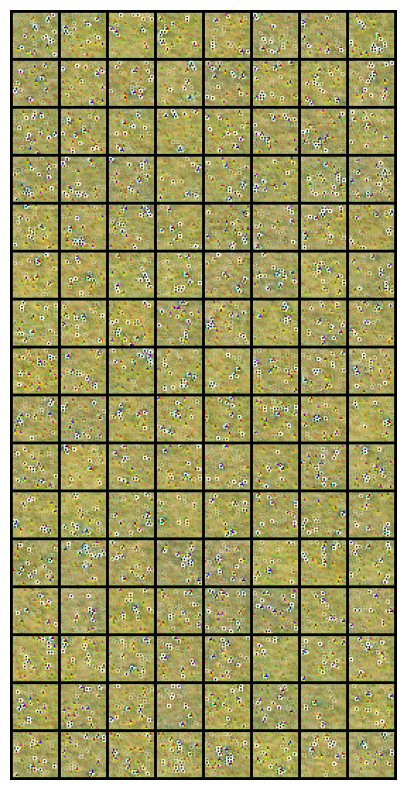

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("run/pruned/ddpm_cifar10_pruned/vis/after_pruning.png")

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.06 KiB | 544.00 KiB/s, done.
From https://github.com/elliotcanter11/Diff-Pruning
   4658a30..fabbfbf  main       -> origin/main
Updating 4658a30..fabbfbf
Fast-forward
 ddpm_train.py | 5 +++++
 1 file changed, 5 insertions(+)


In [ ]:
#Finetune the model and save it at run/finetuned/ddpm_cifar10_pruned_post_training
!bash scripts/finetune_ddpm_cifar10.sh

07/08/2026 16:45:55 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

Loading pruned model from run/pruned/ddpm_cifar10_pruned/pruned/unet_pruned.pth
The config attributes {'rescale_betas_zero_snr': False, 'timestep_spacing': 'leading'} were passed to DDPMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.
07/08/2026 16:45:55 - INFO - __main__ - [RANK 0] Dataset size: 50000
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  s

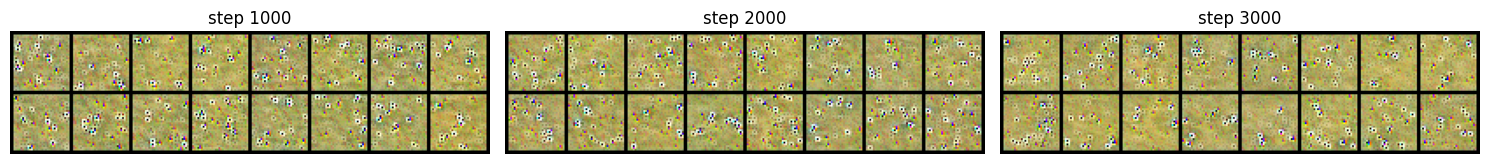

In [ ]:
import glob
import re
from PIL import Image
import matplotlib.pyplot as plt

vis_dir = "run/finetuned/ddpm_cifar10_pruned_post_training/vis"
paths = glob.glob(f"{vis_dir}/iter-*.png")

# sort by the step number embedded in the filename
paths.sort(key=lambda p: int(re.search(r"iter-(\d+)\.png", p).group(1)))

fig, axes = plt.subplots(1, len(paths), figsize=(5 * len(paths), 5))
if len(paths) == 1:
    axes = [axes]

for ax, path in zip(axes, paths):
    step = re.search(r"iter-(\d+)\.png", path).group(1)
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"step {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Pruned: Sample and save images to run/sample/ddpm_cifar10_pruned
!bash scripts/sample_ddpm_cifar10_pruned.sh

In [ ]:
#Pretrained: Sample and save images to run/sample/ddpm_cifar10_pretrained
!bash scripts/sample_ddpm_cifar10_pretrained.sh

In [ ]:
# pre-compute the stats of CIFAR-10 dataset
!python fid_score.py --save-stats data/cifar10_images run/fid_stats_cifar10.npz --device cuda:0 --batch-size 256

In [ ]:
# Compute the FID score of sampled images
!python fid_score.py run/sample/ddpm_cifar10_pruned run/fid_stats_cifar10.npz --device cuda:0 --batch-size 256